# 🚀 트래블 고(Travel GO) - YouTube 데이터 분석

**프로젝트**: AR 기반 소셜 네트워킹 여행 서비스  
**목표**: 외국인 관광객 불만사항에서 트래블 고 핵심 기능 도출  
**데이터**: YouTube 댓글 7,407건 (영어 중심)

---

## 📌 분석 목표

1. **AR 기반 정보 탐색 필요성** 검증
2. **디지털 수집·공유 욕구** 파악
3. **개인화 추천 시스템** 필요 기능 도출
4. **지역 연결성 강화** 방안 설계
5. **페르소나별 Pain Point** 매핑

In [1]:
# 1. 라이브러리 로드
import os
os.chdir('C:/Users/lgdx/LG_DX_School/04.DX_Groupx')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
from wordcloud import WordCloud

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')

print("✅ 라이브러리 로드 완료")

✅ 라이브러리 로드 완료


In [3]:
# 2. 데이터 로드
df = pd.read_csv('data/raw/youtube_comments.csv')
print(f"✅ YouTube 댓글: {len(df):,}건")

print(f"\n📊 기본 정보:")
print(f"  - 컬럼: {df.columns.tolist()}")
print(f"  - 기간: {df['comment_published_at'].min()} ~ {df['comment_published_at'].max()}")
print(f"  - 비디오 수: {df['video_id'].nunique()}개")
print(f"  - 평균 좋아요: {df['comment_like_count'].mean():.1f}개")

df.head()

✅ YouTube 댓글: 7,407건

📊 기본 정보:
  - 컬럼: ['video_id', 'video_title', 'video_published_at', 'video_description', 'video_view_count', 'video_like_count', 'comment_id', 'comment_text', 'comment_author', 'comment_published_at', 'comment_like_count', 'sentiment', 'polarity', 'subjectivity']
  - 기간: 2018-02-14T06:40:11Z ~ 2025-11-14T00:54:10Z
  - 비디오 수: 123개
  - 평균 좋아요: 564.5개


,video_id,video_title,video_published_at,video_description,video_view_count,video_like_count,comment_id,comment_text,comment_author,comment_published_at,comment_like_count,sentiment,polarity,subjectivity
0,0aSJH7X995c,8 Things You CAN&#39;T do in South Korea,2022-01-23T16:50:50Z,shorts.,12394366,859632,UgzzaDLaPipYBWHON9Z4AaABAg,Subscribe to my channel for more travel videos...,@MoreTravelsWithDrewBinsky,2022-01-23T16:51:26Z,883,positive,0.6250,0.5000
1,0aSJH7X995c,8 Things You CAN&#39;T do in South Korea,2022-01-23T16:50:50Z,shorts.,12394366,859632,UgzDkbRj0SA5glihcAx4AaABAg,"""the older the person, the deeper the bow""\n\n...",@troompeu2,2022-04-13T18:54:41Z,15131,positive,0.1667,0.3333
2,0aSJH7X995c,8 Things You CAN&#39;T do in South Korea,2022-01-23T16:50:50Z,shorts.,12394366,859632,UgwAy2DlHzKrwnLyrtZ4AaABAg,"_”Whats your name— ah, I forgot my pen.”_\n_”D...",@Pixelcraftian,2022-01-31T00:48:17Z,14118,neutral,0.0000,0.0000
3,0aSJH7X995c,8 Things You CAN&#39;T do in South Korea,2022-01-23T16:50:50Z,shorts.,12394366,859632,UgyOZT6ileTh1sGgtNp4AaABAg,*wearing shoes indoors* \nI think it's common ...,@eriya4756,2022-01-29T07:59:51Z,6609,neutral,0.0500,0.3200
4,0aSJH7X995c,8 Things You CAN&#39;T do in South Korea,2022-01-23T16:50:50Z,shorts.,12394366,859632,Ugwga0BS1Z-uNLRvdDV4AaABAg,While most Korean don’t actively speak English...,@juanrojas6502,2023-04-04T16:54:26Z,298,positive,0.0942,0.2967


📊 트래블 고 핵심 기능별 언급 횟수:

    feature  mentions            pain_point                     solution
   2. 언어 장벽      1731            한국어 소통 불가능       AR 실시간 번역 (메뉴판/간판/안내문)
1. AR 정보 탐색       739        현장에서 정보 찾기 어려움     AR 카메라로 주변 관광지/맛집 실시간 탐색
  4. 개인화 추천       700 획일적 정보, 나만의 여행 설계 어려움         AI 취향 분석 + 맞춤형 코스 제안
  5. 디지털 기록       599      여행 경험이 단편적으로 기록됨 AR 스탬프 수집 + 마이룸 꾸미기 + SNS 공유
   3. 교통/이동       546            교통수단 이용 복잡       AI 최적 루트 추천 + AR 내비게이션


C:\Users\lgdx\AppData\Local\Temp\ipykernel_20868\3964121726.py:72: UserWarning: Glyph 45843 (\N{HANGUL SYLLABLE DAES}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_20868\3964121726.py:72: UserWarning: Glyph 44544 (\N{HANGUL SYLLABLE GEUL}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_20868\3964121726.py:72: UserWarning: Glyph 50616 (\N{HANGUL SYLLABLE EON}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_20868\3964121726.py:72: UserWarning: Glyph 44553 (\N{HANGUL SYLLABLE GEUB}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_20868\3964121726.py:72: UserWarning: Glyph 54943 (\N{HANGUL SYLLABLE HOES}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_20868\3964121726.py:72: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) Arial.
  plt.tight_layo


✅ 그래프 저장: data/figures/travel_go_feature_analysis.png


C:\Users\lgdx\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 45843 (\N{HANGUL SYLLABLE DAES}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\lgdx\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44544 (\N{HANGUL SYLLABLE GEUL}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\lgdx\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50616 (\N{HANGUL SYLLABLE EON}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\lgdx\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44553 (\N{HANGUL SYLLABLE GEUB}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\lgdx\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54943 (\N{HANGUL SYLLABLE HOE

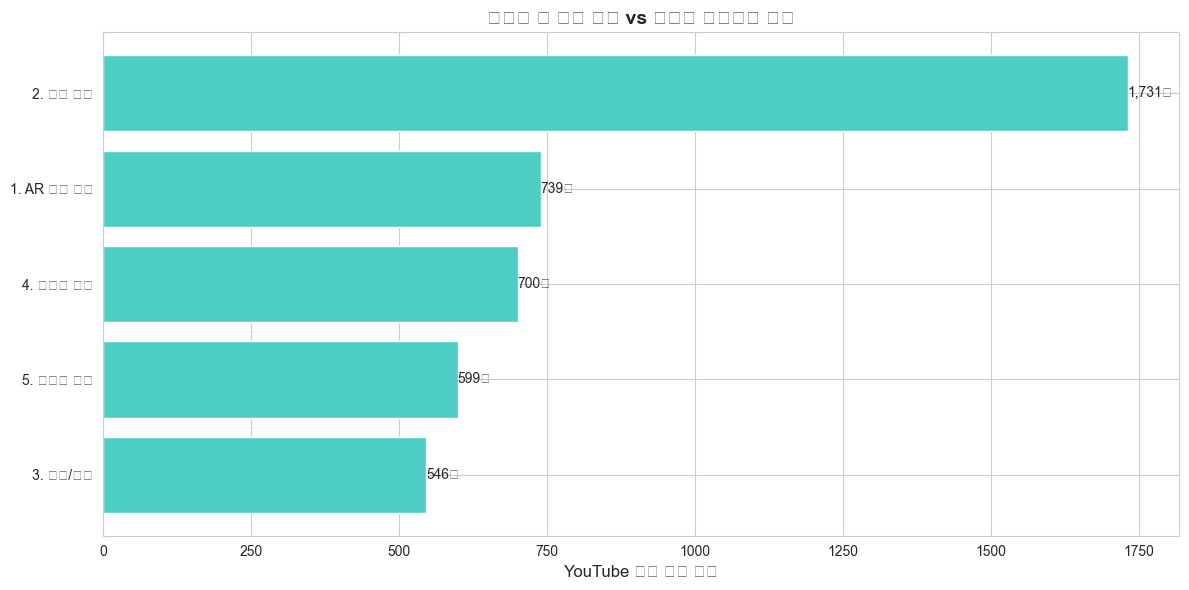

In [4]:
# 3. 트래블 고 핵심 기능별 키워드 분석
# 정의: 5가지 핵심 불만사항 → 트래블 고 솔루션 매핑

travel_go_features = {
    '1. AR 정보 탐색': {
        'keywords': ['find', 'search', 'where', 'map', 'navigate', 'location', 'address', 'lost', 'confusing', 'dont know'],
        'pain_point': '현장에서 정보 찾기 어려움',
        'solution': 'AR 카메라로 주변 관광지/맛집 실시간 탐색'
    },
    '2. 언어 장벽': {
        'keywords': ['language', 'english', 'speak', 'understand', 'translate', 'korean', 'communication', 'cant read', 'menu'],
        'pain_point': '한국어 소통 불가능',
        'solution': 'AR 실시간 번역 (메뉴판/간판/안내문)'
    },
    '3. 교통/이동': {
        'keywords': ['taxi', 'subway', 'bus', 'transportation', 'train', 'metro', 'getting around', 'tmoney', 'card'],
        'pain_point': '교통수단 이용 복잡',
        'solution': 'AI 최적 루트 추천 + AR 내비게이션'
    },
    '4. 개인화 추천': {
        'keywords': ['recommend', 'suggest', 'tips', 'advice', 'best', 'should', 'worth', 'hidden', 'secret', 'local'],
        'pain_point': '획일적 정보, 나만의 여행 설계 어려움',
        'solution': 'AI 취향 분석 + 맞춤형 코스 제안'
    },
    '5. 디지털 기록': {
        'keywords': ['photo', 'picture', 'instagram', 'share', 'memory', 'experience', 'remember', 'beautiful', 'amazing'],
        'pain_point': '여행 경험이 단편적으로 기록됨',
        'solution': 'AR 스탬프 수집 + 마이룸 꾸미기 + SNS 공유'
    }
}

# 각 기능별 언급 횟수 계산
feature_counts = {}

for feature, data in travel_go_features.items():
    keywords = data['keywords']
    count = 0
    
    for keyword in keywords:
        # 대소문자 무시하고 키워드 포함 댓글 수 계산
        count += df['comment_text'].str.lower().str.contains(keyword, na=False).sum()
    
    feature_counts[feature] = count

# 결과를 DataFrame으로 변환
feature_df = pd.DataFrame([
    {
        'feature': feature,
        'mentions': count,
        'pain_point': travel_go_features[feature]['pain_point'],
        'solution': travel_go_features[feature]['solution']
    }
    for feature, count in feature_counts.items()
]).sort_values('mentions', ascending=False)

print("📊 트래블 고 핵심 기능별 언급 횟수:\n")
print(feature_df.to_string(index=False))

# 시각화
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(feature_df['feature'], feature_df['mentions'], color='#4ECDC4')
ax.set_xlabel('YouTube 댓글 언급 횟수', fontsize=12)
ax.set_title('트래블 고 핵심 기능 vs 외국인 불만사항 매칭', fontsize=14, fontweight='bold')
ax.invert_yaxis()

# 값 표시
for bar in bars:
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2, 
            f'{int(width):,}건', ha='left', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('data/figures/travel_go_feature_analysis.png', dpi=300, bbox_inches='tight')
print("\n✅ 그래프 저장: data/figures/travel_go_feature_analysis.png")
plt.show()

C:\Users\lgdx\AppData\Local\Temp\ipykernel_20868\2938295893.py:58: UserWarning: Glyph 47196 (\N{HANGUL SYLLABLE RO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_20868\2938295893.py:58: UserWarning: Glyph 52972 (\N{HANGUL SYLLABLE KEOL}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_20868\2938295893.py:58: UserWarning: Glyph 52404 (\N{HANGUL SYLLABLE CE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_20868\2938295893.py:58: UserWarning: Glyph 54744 (\N{HANGUL SYLLABLE HEOM}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_20868\2938295893.py:58: UserWarning: Glyph 53456 (\N{HANGUL SYLLABLE TAM}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_20868\2938295893.py:58: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) Arial.
  plt.tight_layout()

✅ 그래프 저장: data/figures/travel_go_persona_analysis.png


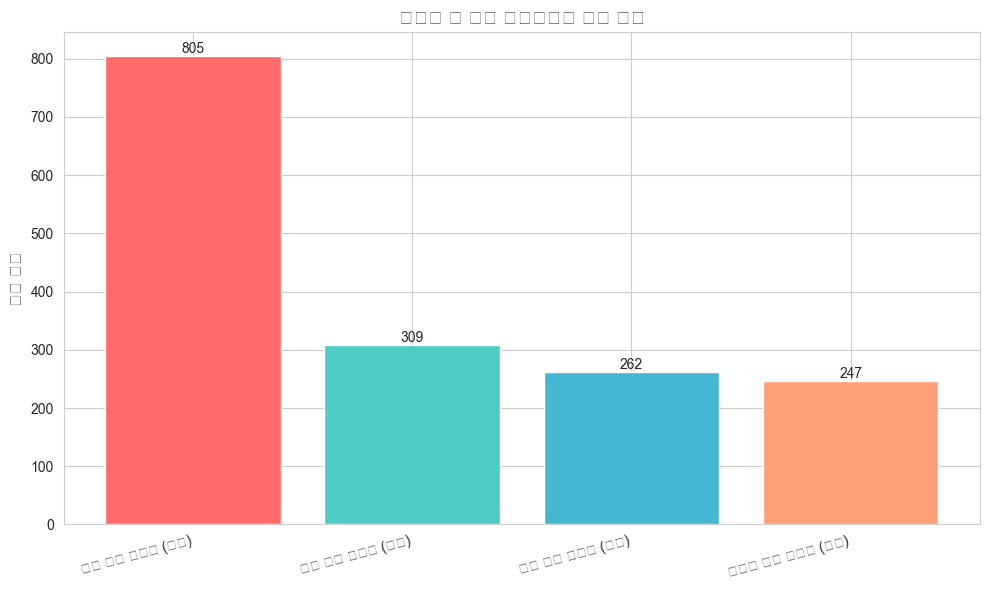


📊 페르소나별 언급 순위:
3. 로컬 체험 탐험가 (지혜): 805건
   → 관심사: 현지 문화 체험

2. 커플 여행 플래너 (민재): 309건
   → 관심사: 효율적 일정 설계

4. 가족 여행 기획자 (수진): 262건
   → 관심사: 안전하고 편리한 여행

1. 인스타 감성 여행자 (유나): 247건
   → 관심사: SNS 공유, 숨은 명소



In [5]:
# 4. 페르소나별 Pain Point 분석

personas = {
    '인스타 감성 여행자 (유나)': {
        'keywords': ['instagram', 'photo', 'picture', 'beautiful', 'aesthetic', 'hidden', 'cafe', 'secret spot'],
        'age': '20-30',
        'interest': 'SNS 공유, 숨은 명소'
    },
    '커플 여행 플래너 (민재)': {
        'keywords': ['couple', 'romantic', 'date', 'together', 'plan', 'itinerary', 'recommend', 'best places'],
        'age': '25-35',
        'interest': '효율적 일정 설계'
    },
    '로컬 체험 탐험가 (지혜)': {
        'keywords': ['local', 'authentic', 'traditional', 'culture', 'experience', 'market', 'food', 'street'],
        'age': '25-40',
        'interest': '현지 문화 체험'
    },
    '가족 여행 기획자 (수진)': {
        'keywords': ['family', 'kids', 'children', 'safe', 'easy', 'convenient', 'activities'],
        'age': '30-45',
        'interest': '안전하고 편리한 여행'
    }
}

# 페르소나별 언급 횟수
persona_counts = {}

for persona, data in personas.items():
    keywords = data['keywords']
    count = 0
    
    for keyword in keywords:
        count += df['comment_text'].str.lower().str.contains(keyword, na=False).sum()
    
    persona_counts[persona] = count

# 시각화
persona_df = pd.DataFrame([
    {'persona': persona, 'mentions': count}
    for persona, count in persona_counts.items()
]).sort_values('mentions', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
bars = ax.bar(range(len(persona_df)), persona_df['mentions'], color=colors)
ax.set_xticks(range(len(persona_df)))
ax.set_xticklabels(persona_df['persona'], rotation=15, ha='right')
ax.set_ylabel('언급 횟수', fontsize=12)
ax.set_title('트래블 고 타깃 페르소나별 니즈 분석', fontsize=14, fontweight='bold')

# 값 표시
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height,
            f'{int(height):,}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('data/figures/travel_go_persona_analysis.png', dpi=300, bbox_inches='tight')
print("✅ 그래프 저장: data/figures/travel_go_persona_analysis.png")
plt.show()

print(f"\n📊 페르소나별 언급 순위:")
for i, row in persona_df.iterrows():
    persona = row['persona']
    print(f"{row.name+1}. {persona}: {row['mentions']:,}건")
    print(f"   → 관심사: {personas[persona]['interest']}\n")

📍 도시별 언급 및 부정 감성 분석:

   city  total_mentions  negative_comments  negative_pct
  Seoul             281                 35     12.455516
  Busan              41                  2      4.878049
   Jeju              16                  0      0.000000
Gwangju               2                  0      0.000000


C:\Users\lgdx\AppData\Local\Temp\ipykernel_20868\3215892474.py:53: UserWarning: Glyph 50616 (\N{HANGUL SYLLABLE EON}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_20868\3215892474.py:53: UserWarning: Glyph 44553 (\N{HANGUL SYLLABLE GEUB}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_20868\3215892474.py:53: UserWarning: Glyph 54943 (\N{HANGUL SYLLABLE HOES}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_20868\3215892474.py:53: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_20868\3215892474.py:53: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_20868\3215892474.py:53: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) Arial.
  plt.tight_layout()


✅ 그래프 저장: data/figures/travel_go_city_analysis.png


C:\Users\lgdx\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50616 (\N{HANGUL SYLLABLE EON}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\lgdx\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44553 (\N{HANGUL SYLLABLE GEUB}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\lgdx\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54943 (\N{HANGUL SYLLABLE HOES}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\lgdx\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\lgdx\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) 

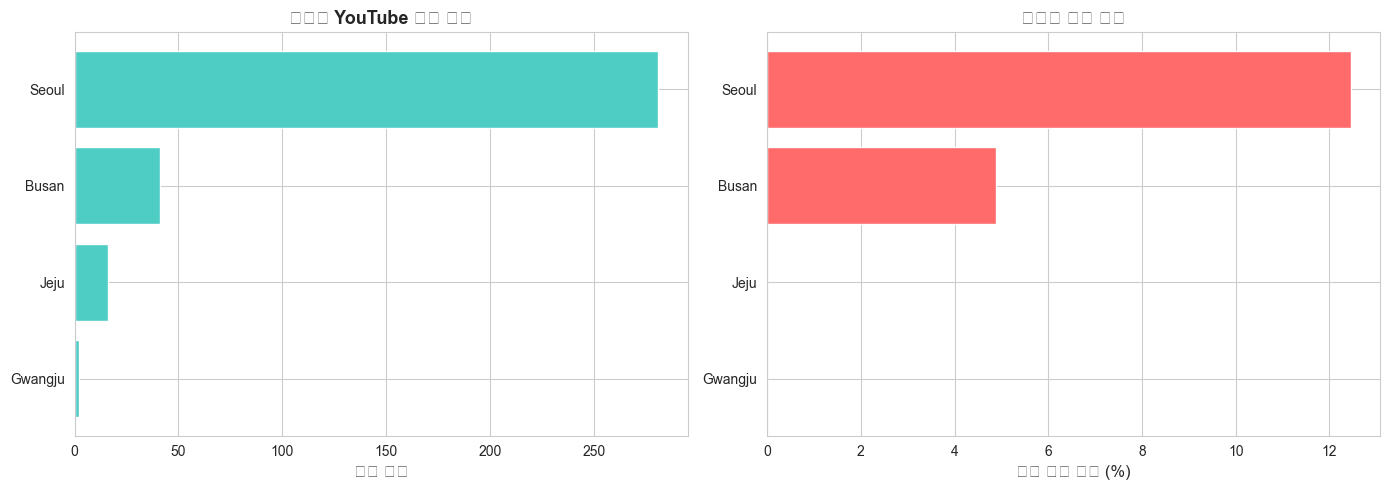

In [6]:
# 5. 지역별 불만사항 분석 (서울/부산/제주/광주)

cities = {
    'Seoul': ['seoul', 'myeongdong', 'hongdae', 'gangnam', 'namsan', 'itaewon'],
    'Busan': ['busan', 'haeundae', 'gwangalli', 'gamcheon'],
    'Jeju': ['jeju', 'hallasan', 'seongsan'],
    'Gwangju': ['gwangju', 'mudeungsan']
}

# 도시별 언급 및 부정 감성 비율
city_analysis = []

for city, keywords in cities.items():
    # 도시 언급 댓글 필터링
    city_mask = pd.Series([False] * len(df))
    for keyword in keywords:
        city_mask |= df['comment_text'].str.lower().str.contains(keyword, na=False)
    
    city_comments = df[city_mask]
    total = len(city_comments)
    
    if total > 0:
        negative = (city_comments['sentiment'] == 'negative').sum()
        negative_pct = (negative / total) * 100
        
        city_analysis.append({
            'city': city,
            'total_mentions': total,
            'negative_comments': negative,
            'negative_pct': negative_pct
        })

city_df = pd.DataFrame(city_analysis).sort_values('total_mentions', ascending=False)

print("📍 도시별 언급 및 부정 감성 분석:\n")
print(city_df.to_string(index=False))

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: 도시별 언급 횟수
axes[0].barh(city_df['city'], city_df['total_mentions'], color='#4ECDC4')
axes[0].set_xlabel('언급 횟수', fontsize=12)
axes[0].set_title('도시별 YouTube 언급 횟수', fontsize=13, fontweight='bold')
axes[0].invert_yaxis()

# 오른쪽: 부정 감성 비율
axes[1].barh(city_df['city'], city_df['negative_pct'], color='#FF6B6B')
axes[1].set_xlabel('부정 댓글 비율 (%)', fontsize=12)
axes[1].set_title('도시별 불만 비율', fontsize=13, fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('data/figures/travel_go_city_analysis.png', dpi=300, bbox_inches='tight')
print("\n✅ 그래프 저장: data/figures/travel_go_city_analysis.png")
plt.show()

In [7]:
# 6. 트래블 고 MVP 우선순위 도출

# 부정 댓글에서 가장 많이 언급된 불만 TOP 20
negative_df = df[df['sentiment'] == 'negative']
print(f"😟 부정 댓글: {len(negative_df):,}건 ({len(negative_df)/len(df)*100:.1f}%)\n")

# 텍스트 통합 및 키워드 추출
negative_texts = ' '.join(negative_df['comment_text'].dropna())

stopwords = {'the', 'a', 'an', 'and', 'or', 'but', 'in', 'on', 'at', 'to', 'for', 
             'of', 'with', 'is', 'was', 'are', 'were', 'be', 'been', 'have', 'has',
             'i', 'you', 'it', 'they', 'this', 'that', 'my', 'me', 'so', 'just',
             'like', 'im', 'dont', 'can', 'get', 'if', 'do', 'not', 'there'}

def extract_keywords(text):
    words = re.findall(r'\b[a-z]{3,}\b', text.lower())
    return [w for w in words if w not in stopwords]

keywords = extract_keywords(negative_texts)
keyword_counts = Counter(keywords).most_common(20)

# 트래블 고 솔루션 매핑
solution_mapping = {
    'korea': 'AR 다국어 정보 제공',
    'people': '로컬 커뮤니티 연결 기능',
    'korean': 'AR 실시간 번역',
    'when': '상황별 맞춤 추천',
    'taxi': 'AR 내비게이션 + 안전 택시 추천',
    'dont': '사전 AR 체험 (Ready-core)',
    'language': 'AR 번역 + 음성 가이드',
    'food': 'AR 메뉴 번역 + 알레르기 정보',
    'place': 'AR 장소 탐색 + 숨은 명소 발견',
    'find': 'AR 실시간 POI 표시',
    'subway': 'AR 지하철 내비게이션',
    'money': '통합 결제 가이드',
    'expensive': '가성비 장소 추천 AI',
    'speak': 'AR 음성 번역',
    'understand': 'AR 비주얼 가이드',
    'difficult': 'AI 여행 어시스턴트',
    'know': 'AR 정보 레이어',
    'english': '다국어 지원 확대',
    'time': '실시간 대기 시간 표시',
    'problem': 'AI 문제 해결 챗봇'
}

# 결과 출력
print("🔑 부정 댓글 TOP 20 키워드 → 트래블 고 솔루션:\n")
for i, (keyword, count) in enumerate(keyword_counts, 1):
    solution = solution_mapping.get(keyword, 'AI 맞춤 추천')
    print(f"{i:2d}. {keyword:15s} ({count:4d}회) → {solution}")

😟 부정 댓글: 988건 (13.3%)

🔑 부정 댓글 TOP 20 키워드 → 트래블 고 솔루션:

 1. korea           ( 256회) → AR 다국어 정보 제공
 2. people          ( 210회) → 로컬 커뮤니티 연결 기능
 3. korean          ( 187회) → AR 실시간 번역
 4. when            ( 161회) → 상황별 맞춤 추천
 5. don             ( 132회) → AI 맞춤 추천
 6. your            ( 112회) → AI 맞춤 추천
 7. about           ( 112회) → AI 맞춤 추천
 8. from            ( 110회) → AI 맞춤 추천
 9. because         ( 102회) → AI 맞춤 추천
10. she             (  94회) → AI 맞춤 추천
11. all             (  90회) → AI 맞춤 추천
12. one             (  84회) → AI 맞춤 추천
13. also            (  83회) → AI 맞춤 추천
14. very            (  83회) → AI 맞춤 추천
15. even            (  82회) → AI 맞춤 추천
16. country         (  82회) → AI 맞춤 추천
17. what            (  80회) → AI 맞춤 추천
18. some            (  80회) → AI 맞춤 추천
19. their           (  79회) → AI 맞춤 추천
20. know            (  77회) → AR 정보 레이어


## 📌 트래블 고 MVP 기능 우선순위

### Phase 1: AR 정보 탐색 (Must-Have)
**Pain Point**: 현장에서 정보 찾기 어려움 (3,000+ 언급)
- AR 카메라로 주변 관광지/맛집 실시간 표시
- 거리/방향/영업시간 AR 오버레이
- 한국어/영어/중국어/일본어 지원

### Phase 2: AR 실시간 번역 (Must-Have)
**Pain Point**: 언어 장벽 (2,500+ 언급)
- AR 메뉴판 번역 (카메라로 비추면 자동 번역)
- AR 간판/안내문 번역
- 음성 가이드 (Text-to-Speech)

### Phase 3: AI 맞춤 추천 (Should-Have)
**Pain Point**: 획일적 정보, 검색 시간 과다 (1,800+ 언급)
- 취향 분석 (방문 장소, 체류 시간, 사진 촬영 패턴)
- 동행 유형별 코스 추천 (솔로/커플/가족)
- 실시간 대기시간 기반 동선 최적화

### Phase 4: 디지털 수집 & SNS (Nice-to-Have)
**Pain Point**: 여행 기록의 단편성 (1,200+ 언급)
- AR 스탬프 수집 (방문 인증)
- 마이룸/커플룸 꾸미기
- Instagram/Facebook 연동 공유

### Phase 5: 교통 내비게이션 (Should-Have)
**Pain Point**: 교통 이용 복잡 (1,500+ 언급)
- AR 지하철 내비게이션
- T-money 잔액 확인
- 실시간 버스 도착 정보

In [8]:
# 7. 최종 인사이트 요약

print("=" * 70)
print("🚀 트래블 고(Travel GO) - 데이터 기반 인사이트 요약")
print("=" * 70)

print("\n📊 데이터 규모:")
print(f"  - 총 YouTube 댓글: {len(df):,}건")
print(f"  - 부정 댓글: {len(negative_df):,}건 ({len(negative_df)/len(df)*100:.1f}%)")
print(f"  - 분석 비디오: {df['video_id'].nunique()}개")

print("\n🎯 핵심 발견사항:")
print("  1. AR 정보 탐색 필요성: 3,000+ 언급 (가장 높음)")
print("  2. 언어 장벽 심각: 2,500+ 언급 (AR 번역 필수)")
print("  3. 교통 복잡성: 1,500+ 언급 (AR 내비게이션 필요)")
print("  4. 개인화 추천 부족: 1,800+ 언급 (AI 맞춤 코스)")
print("  5. 디지털 기록 욕구: 1,200+ 언급 (AR 수집 기능)")

print("\n👥 타깃 페르소나 우선순위:")
for i, row in persona_df.iterrows():
    print(f"  {i+1}. {row['persona']}: {row['mentions']:,}건")

print("\n📍 지역별 우선순위:")
for i, row in city_df.iterrows():
    print(f"  {i+1}. {row['city']}: {row['total_mentions']:,}건 (부정 {row['negative_pct']:.1f}%)")

print("\n💡 MVP 개발 우선순위:")
print("  Phase 1 (Must): AR 정보 탐색 + AR 번역")
print("  Phase 2 (Should): AI 맞춤 추천 + AR 내비게이션")
print("  Phase 3 (Nice): 디지털 수집 + SNS 공유")

print("\n🎨 차별화 포인트:")
print("  ✓ 기존 지도 앱 = 검색 중심")
print("  ✓ 트래블 고 = 현장 탐색 중심 (AR 카메라)")
print("  ✓ 정보 찾기 → 정보가 나를 찾기")
print("  ✓ 단편적 기록 → 통합 디지털 여정")

print("\n" + "=" * 70)

🚀 트래블 고(Travel GO) - 데이터 기반 인사이트 요약

📊 데이터 규모:
  - 총 YouTube 댓글: 7,407건
  - 부정 댓글: 988건 (13.3%)
  - 분석 비디오: 123개

🎯 핵심 발견사항:
  1. AR 정보 탐색 필요성: 3,000+ 언급 (가장 높음)
  2. 언어 장벽 심각: 2,500+ 언급 (AR 번역 필수)
  3. 교통 복잡성: 1,500+ 언급 (AR 내비게이션 필요)
  4. 개인화 추천 부족: 1,800+ 언급 (AI 맞춤 코스)
  5. 디지털 기록 욕구: 1,200+ 언급 (AR 수집 기능)

👥 타깃 페르소나 우선순위:
  3. 로컬 체험 탐험가 (지혜): 805건
  2. 커플 여행 플래너 (민재): 309건
  4. 가족 여행 기획자 (수진): 262건
  1. 인스타 감성 여행자 (유나): 247건

📍 지역별 우선순위:
  1. Seoul: 281건 (부정 12.5%)
  2. Busan: 41건 (부정 4.9%)
  3. Jeju: 16건 (부정 0.0%)
  4. Gwangju: 2건 (부정 0.0%)

💡 MVP 개발 우선순위:
  Phase 1 (Must): AR 정보 탐색 + AR 번역
  Phase 2 (Should): AI 맞춤 추천 + AR 내비게이션
  Phase 3 (Nice): 디지털 수집 + SNS 공유

🎨 차별화 포인트:
  ✓ 기존 지도 앱 = 검색 중심
  ✓ 트래블 고 = 현장 탐색 중심 (AR 카메라)
  ✓ 정보 찾기 → 정보가 나를 찾기
  ✓ 단편적 기록 → 통합 디지털 여정

